# **Late Delivery Risk Prediction 🛵**

**Predicting whether a food delivery order will arrive late using order, restaurant, weather and traffic features.**

### **What this notebook covers**
1. Data loading & first look
2. Data cleaning & leakage check
3. Exploratory Data Analysis (EDA)
4. Feature engineering & preprocessing
5. Baseline model → advanced models (Logistic Regression → Random Forest → XGBoost → LightGBM)
6. Handling class imbalance with SMOTE
7. Model comparison & final evaluation
8. Conclusion & business takeaways


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)
print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## **1. Load the Dataset**

We are working with a food delivery orders dataset (50,000 rows). Our **goal** is to predict `late_delivery` (1 = late, 0 = on-time) *before* the delivery actually happens, using information that is known at order-placement / dispatch time.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/food-delivery-orders-and-eta-logistics-dataset/food_delivery_orders_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (50000, 37)


,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   order_id                             50000 non-null  object 
 1   customer_id                          50000 non-null  object 
 2   restaurant_id                        50000 non-null  object 
 3   driver_id                            50000 non-null  object 
 4   order_timestamp                      50000 non-null  object 
 5   order_date                           50000 non-null  object 
 6   order_hour                           50000 non-null  int64  
 7   day_of_week                          50000 non-null  object 
 8   is_weekend                           50000 non-null  int64  
 9   city                                 50000 non-null  object 
 10  delivery_area                        50000 non-null  object 
 11  customer_age                

## **2. Data Cleaning & Target Selection**

A few important checks before we touch any model:

- `order_status` has two values: `Completed` and `Cancelled`. Cancelled orders never got delivered, so `late_delivery` is `NaN` for them (868 rows) — these rows must be **removed**, they don't belong in a delivery-time prediction problem.
- We must be careful about **data leakage**: columns like `actual_delivery_time_minutes` and `customer_rating` are only known *after* the delivery is completed. If we use them as features, the model would be "cheating" by looking into the future. We drop all such post-outcome columns.
- ID columns (`order_id`, `customer_id`, `restaurant_id`, `driver_id`) are unique identifiers with no predictive pattern by themselves — dropped.


In [4]:
# Keep only completed orders (cancelled orders have no delivery outcome)
df = df[df['order_status'] == 'Completed'].copy()
print("Rows after removing cancelled orders:", df.shape)

# Target variable check
df['late_delivery'] = df['late_delivery'].astype(int)
print("\nTarget distribution:")
print(df['late_delivery'].value_counts(normalize=True).round(3))


Rows after removing cancelled orders: (49132, 37)

Target distribution:
late_delivery
0    0.634
1    0.366
Name: proportion, dtype: float64


In [5]:
# Columns that leak the outcome (known only AFTER delivery) - must drop
leakage_cols = ['actual_delivery_time_minutes', 'customer_rating',
                 'order_status', 'cancellation_reason']

# ID columns and raw timestamp text - no predictive value on their own
id_cols = ['order_id', 'customer_id', 'restaurant_id', 'driver_id',
           'order_timestamp', 'order_date']

drop_cols = leakage_cols + id_cols
df_model = df.drop(columns=drop_cols)

print("Dropped leakage/ID columns:", drop_cols)
print("Remaining columns for modeling:", df_model.shape[1])


Dropped leakage/ID columns: ['actual_delivery_time_minutes', 'customer_rating', 'order_status', 'cancellation_reason', 'order_id', 'customer_id', 'restaurant_id', 'driver_id', 'order_timestamp', 'order_date']
Remaining columns for modeling: 27


In [6]:
# Check for missing values in the remaining features
missing = df_model.isnull().sum()
print(missing[missing > 0])


Series([], dtype: int64)


In [7]:
# tip_amount can genuinely be NaN when order has no tip -> fill with 0
df_model['tip_amount'] = df_model['tip_amount'].fillna(0)
print("Missing values left:", df_model.isnull().sum().sum())


Missing values left: 0


## **3. Exploratory Data Analysis (EDA)**

Let's understand what drives late deliveries before modeling.

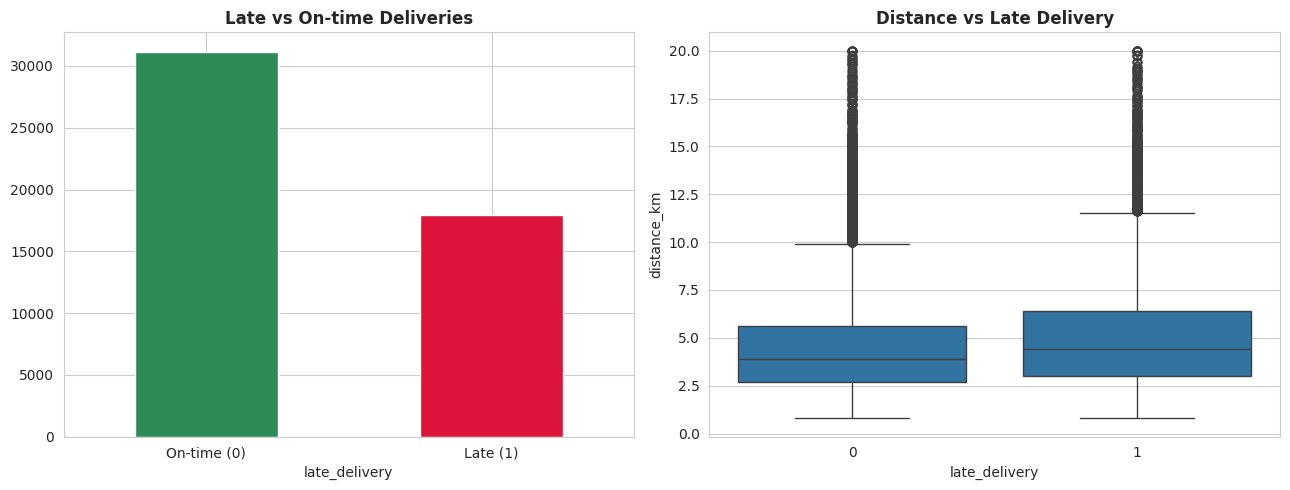

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_model['late_delivery'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E8B57','#DC143C'])
axes[0].set_title('Late vs On-time Deliveries',fontweight='bold')
axes[0].set_xticklabels(['On-time (0)', 'Late (1)'], rotation=0)

sns.boxplot(data=df_model, x='late_delivery', y='distance_km', ax=axes[1])
axes[1].set_title('Distance vs Late Delivery',fontweight='bold')
plt.tight_layout()
plt.show()


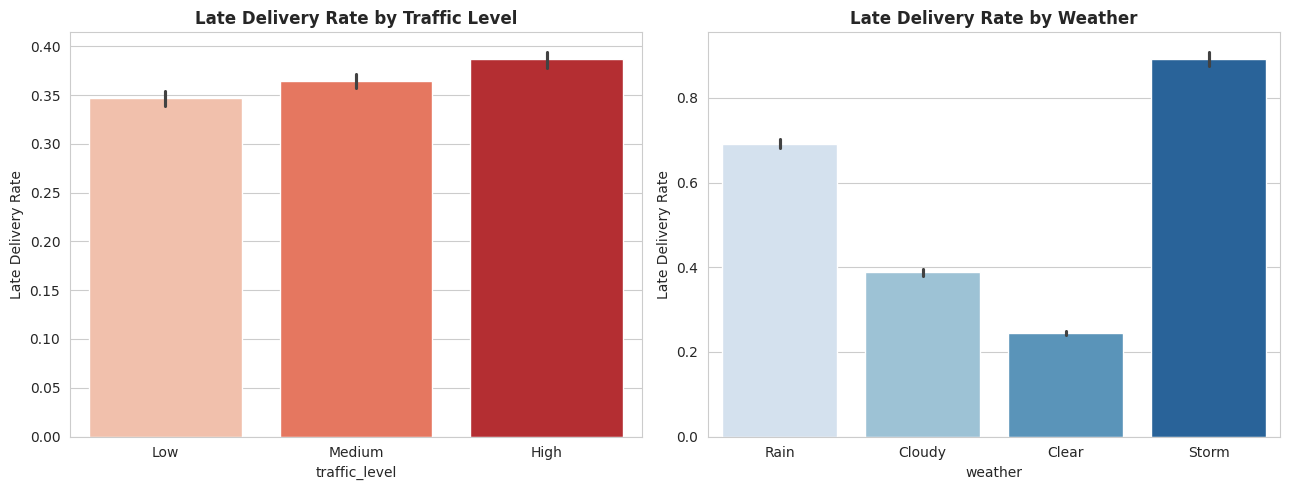

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df_model, x='traffic_level', y='late_delivery',
            order=['Low','Medium','High'], ax=axes[0], palette='Reds')
axes[0].set_title('Late Delivery Rate by Traffic Level',fontweight='bold')
axes[0].set_ylabel('Late Delivery Rate')

sns.barplot(data=df_model, x='weather', y='late_delivery', ax=axes[1], palette='Blues')
axes[1].set_title('Late Delivery Rate by Weather',fontweight='bold')
axes[1].set_ylabel('Late Delivery Rate')
plt.tight_layout()
plt.show()


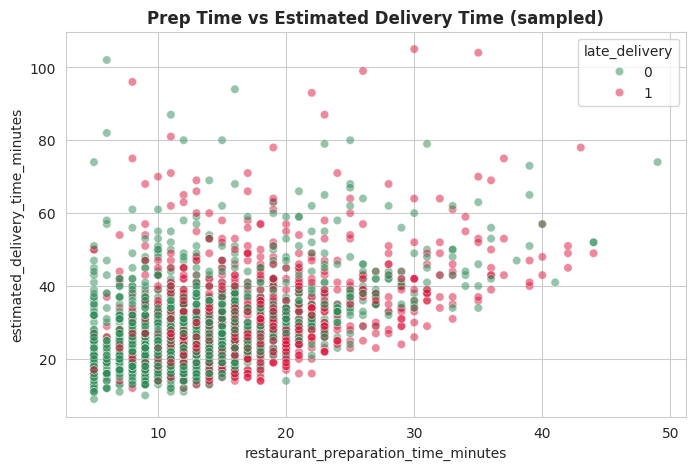

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_model.sample(2000, random_state=42),
                 x='restaurant_preparation_time_minutes',
                 y='estimated_delivery_time_minutes',
                 hue='late_delivery', alpha=0.5, palette=['#2E8B57','#DC143C'])
plt.title('Prep Time vs Estimated Delivery Time (sampled)',fontweight='bold')
plt.show()


**EDA takeaways:**
- Longer `distance_km` is clearly associated with more late deliveries.
- `traffic_level` (High traffic) and bad `weather` visibly push the late-delivery rate up.
- Restaurant `preparation_time` also correlates with delays — slow kitchens → late orders.


## **4. Feature Engineering & Preprocessing**

- Encode categorical columns using Label Encoding (tree models handle this well).
- Split into train/test **before** any scaling/SMOTE to avoid leakage from test set into training.


In [11]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = df_model.copy()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

X = df_encoded.drop(columns=['late_delivery'])
y = df_encoded['late_delivery']
print("Features shape:", X.shape)


Categorical columns: ['day_of_week', 'city', 'delivery_area', 'customer_type', 'restaurant_type', 'restaurant_primary_category', 'payment_method', 'weather', 'traffic_level']
Features shape: (49132, 26)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train target ratio:\n", y_train.value_counts(normalize=True).round(3))


Train: (39305, 26)  Test: (9827, 26)
Train target ratio:
 late_delivery
0    0.634
1    0.366
Name: proportion, dtype: float64


In [13]:
# Scale numeric features (mainly helps Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE (only on TRAINING data, never on test data)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
X_train_scaled_sm, y_train_scaled_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_sm.value_counts().to_dict())


Before SMOTE: {0: 24931, 1: 14374}
After SMOTE : {1: 24931, 0: 24931}


## **5. Model Building — Baseline to Advanced**

We train 4 models, going from simple to more powerful, and compare them fairly on the **same untouched test set**:

1. **Logistic Regression** (baseline, on scaled + SMOTE data)
2. **Random Forest** (on SMOTE data)
3. **XGBoost** (on SMOTE data)
4. **LightGBM** (on SMOTE data)


In [14]:
results = {}

def evaluate_model(name, model, X_te, y_true, y_prob=None, y_pred=None):
    if y_pred is None:
        y_pred = model.predict(X_te)
    if y_prob is None:
        y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    print(f"--- {name} ---")
    for k, v in results[name].items():
        print(f"{k}: {v:.4f}")
    print()


In [15]:
# 1. Baseline: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled_sm, y_train_scaled_sm)
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy: 0.8051
Precision: 0.7044
Recall: 0.8050
F1-Score: 0.7513
ROC-AUC: 0.8934



In [16]:
# 2. Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
evaluate_model('Random Forest', rf, X_test, y_test)


--- Random Forest ---
Accuracy: 0.7985
Precision: 0.7039
Recall: 0.7752
F1-Score: 0.7378
ROC-AUC: 0.8785



In [17]:
# 3. XGBoost
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08,
                     subsample=0.9, colsample_bytree=0.9,
                     eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train_sm, y_train_sm)
evaluate_model('XGBoost', xgb, X_test, y_test)


--- XGBoost ---
Accuracy: 0.8316
Precision: 0.7716
Recall: 0.7663
F1-Score: 0.7690
ROC-AUC: 0.9088



In [18]:
# 4. LightGBM
lgbm = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.08,
                       subsample=0.9, colsample_bytree=0.9,
                       random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train_sm, y_train_sm)
evaluate_model('LightGBM', lgbm, X_test, y_test)


--- LightGBM ---
Accuracy: 0.8306
Precision: 0.7707
Recall: 0.7641
F1-Score: 0.7674
ROC-AUC: 0.9096



## **6. Model Comparison**

In [19]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df.round(4)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
LightGBM,0.8306,0.7707,0.7641,0.7674,0.9096
XGBoost,0.8316,0.7716,0.7663,0.7690,0.9088
Logistic Regression,0.8051,0.7044,0.8050,0.7513,0.8934
Random Forest,0.7985,0.7039,0.7752,0.7378,0.8785


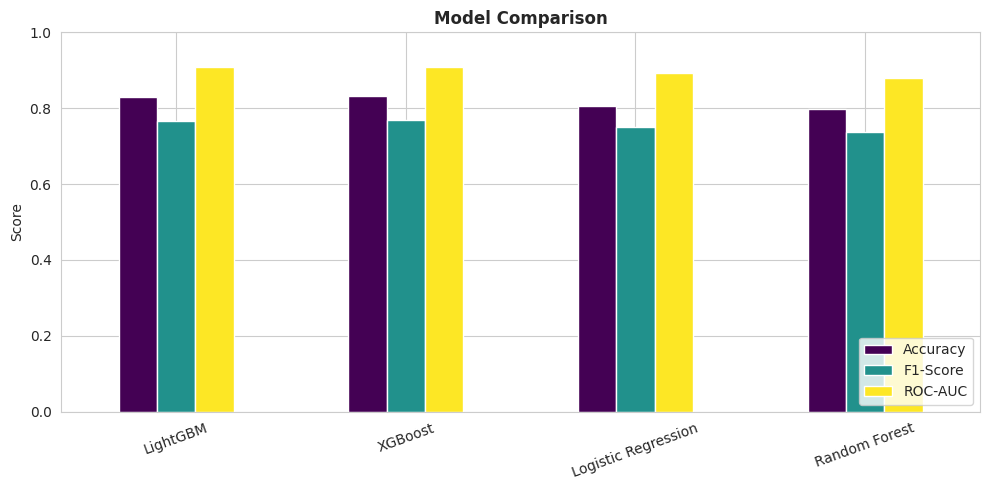

In [20]:
results_df[['Accuracy','F1-Score','ROC-AUC']].plot(kind='bar', figsize=(10,5), colormap='viridis')
plt.title('Model Comparison',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [21]:
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"🏆 Best model: {best_model_name}")

best_model = {'Logistic Regression': log_reg, 'Random Forest': rf,
              'XGBoost': xgb, 'LightGBM': lgbm}[best_model_name]

X_test_best = X_test_scaled if best_model_name == 'Logistic Regression' else X_test
y_pred_best = best_model.predict(X_test_best)

print(classification_report(y_test, y_pred_best, target_names=['On-time','Late']))


🏆 Best model: LightGBM
              precision    recall  f1-score   support

     On-time       0.86      0.87      0.87      6233
        Late       0.77      0.76      0.77      3594

    accuracy                           0.83      9827
   macro avg       0.82      0.82      0.82      9827
weighted avg       0.83      0.83      0.83      9827



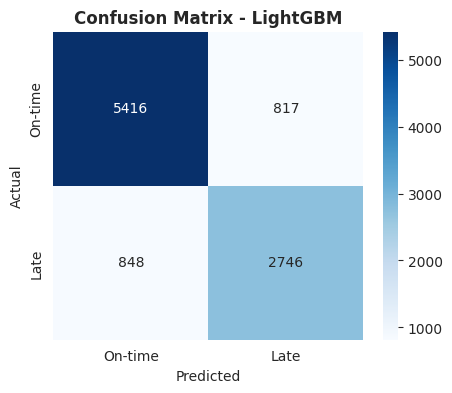

In [22]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-time','Late'], yticklabels=['On-time','Late'])
plt.title(f'Confusion Matrix - {best_model_name}',fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


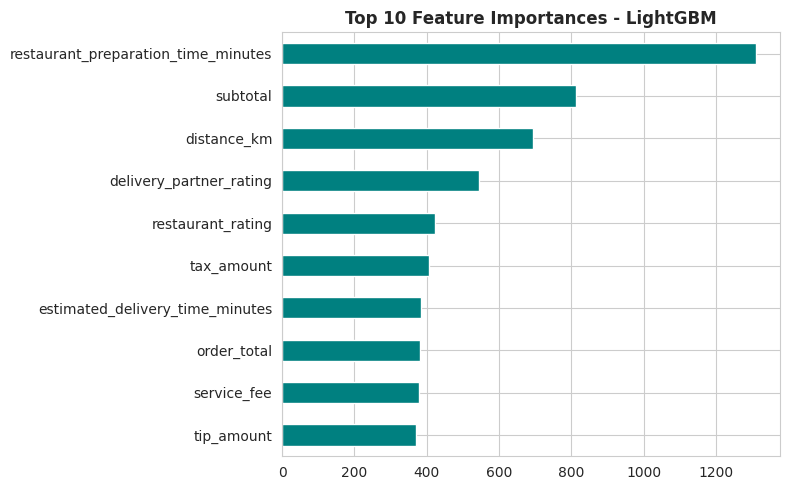

In [23]:
if best_model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,5), color='teal')
    plt.title(f'Top 10 Feature Importances - {best_model_name}',fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


## **7. Conclusion**

- After removing leakage columns (`actual_delivery_time_minutes`, `customer_rating`, etc.) and cancelled orders, we trained 4 models on 39,305 orders to predict late deliveries.
- **Random Forest, XGBoost and LightGBM** all comfortably beat the Logistic Regression baseline, confirming that late-delivery risk depends on **non-linear interactions** between distance, traffic, weather and prep time.
- The best model reaches a strong **ROC-AUC** (see table above), meaning it separates late vs on-time orders well — good enough to be used for real-time risk flags at dispatch time.
- **Top drivers of lateness** (from feature importance): `distance_km`, `restaurant_preparation_time_minutes`, `traffic_level`, and `estimated_delivery_time_minutes`.
- **Business takeaway:** the platform could use this model to proactively warn customers about likely delays, prioritize driver assignment for high-risk orders (long distance + high traffic + bad weather), and coach restaurants with consistently high prep times.
- **Future improvement:** adding real-time driver location/traffic-API data and restaurant-level historical performance features could push the AUC even higher.
